# Transparency–Correctness Trade-Off: Spearman Correlation Analysis
## Cross-Platform LLM Reasoning Evaluation

This notebook addresses Reviewer #2's concern that the transparency–correctness
trade-off claim is purely descriptive and lacks statistical validation.

We compute **Spearman rank correlation** between step-accuracy (transparency proxy)
and final score (correctness proxy) at two levels of analysis:

| Level | Unit | n per config |
|---|---|---|
| **Model-level** | Per-model aggregate means | 7 (UC), 9 (Nebius) |
| **Problem-level** | Per-problem scores within each model | 79 per model |

Both configurations are analysed independently:
- University Cluster (UC) — 7 models, 79 problems
- Nebius AI Studio — 9 models, 79 problems

### Why Spearman?
- Non-parametric: no normality assumption on cosine-similarity scores
- Robust to outliers (e.g., Mistral-7B, DeepSeek-R1)
- Appropriate for small n at model level

---
### Data upload
Upload the same `data.zip` used for the Tukey HSD notebook.

---
## 1. Setup

In [ ]:
import numpy as np
import pandas as pd
import json, os, zipfile, io
import matplotlib.pyplot as plt
from scipy import stats

print('✓ Dependencies loaded')

✓ Dependencies loaded


---
## 2. Upload data.zip and Load Files

In [ ]:
from google.colab import files as colab_files

UC_FILES = {
    'Phi-3-mini-4k-instruct_79problems.json'    : 'Phi-3-mini',
    'Phi-4-mini-instruct_79problems.json'        : 'Phi-4-mini',
    'Meta-Llama-3.1-8B-Instruct_79problems.json' : 'LLaMA-3.1-8B',
    'Phi-3.5-MoE-instruct_79problems.json'       : 'Phi-3.5-MoE',
    'Qwen2-7B-Instruct_79problems.json'          : 'Qwen2-7B',
    'falcon-mamba-7b-instruct_79problems.json'   : 'Falcon-Mamba-7B',
    'Mistral-7B-Instruct-v0.1_79problems.json'   : 'Mistral-7B',
}

NEBIUS_FILES = {
    'reasoning_evaluation_results_Hermes-4-70B_79.json'                  : 'Hermes-4-70B',
    'reasoning_evaluation_results_Hermes-4-405B_79.json'                 : 'Hermes-4-405B',
    'reasoning_evaluation_results_Meta-Llama-3.1-405B-Instruct_79.json'  : 'LLaMA-3.1-405B',
    'reasoning_evaluation_results_Llama-3.3-70B-Instruct_79.json'        : 'LLaMA-3.3-70B',
    'reasoning_evaluation_results_Qwen3-235B-A22B-Instruct-2507_79.json' : 'Qwen3-235B',
    'reasoning_evaluation_results_Qwen3-30B-A3B-Instruct-2507_79.json'   : 'Qwen3-30B',
    'reasoning_evaluation_results_DeepSeek-R1-0528_79.json'              : 'DeepSeek-R1',
    'reasoning_evaluation_results_gpt-oss-20b_79.json'                   : 'GPT-OSS-20B',
    'reasoning_evaluation_results_gpt-oss-120b_79.json'                  : 'GPT-OSS-120B',
}

def load_data_from_zip(zip_bytes, file_map):
    data = {}
    with zipfile.ZipFile(io.BytesIO(zip_bytes)) as zf:
        available = {
            os.path.basename(n): n
            for n in zf.namelist()
            if not n.startswith('__MACOSX') and n.endswith('.json')
        }
        for fname, label in file_map.items():
            if fname in available:
                with zf.open(available[fname]) as f:
                    d = json.load(f)
                evals = d.get('evaluations', [])
                problems = [
                    (e['average_score'],
                     float(e['average_step_score']) if e.get('average_step_score') is not None
                     else np.nan)
                    for e in evals if e and 'average_score' in e
                ]
                data[label] = problems
                final_m = np.mean([p[0] for p in problems])
                step_m  = np.nanmean([p[1] for p in problems])
                print(f'  ✓ {label:<22}  n={len(problems):>2}  '
                      f'final={final_m:.4f}  step={step_m:.4f}')
            else:
                print(f'  ✗ NOT FOUND: {fname}')
    return data

print('📤 Upload data.zip ...')
uploaded  = colab_files.upload()
zip_bytes = next(iter(uploaded.values()))

print('\n── University Cluster (79 problems) ──')
uc_data = load_data_from_zip(zip_bytes, UC_FILES)

print('\n── Nebius AI Studio (79 problems) ──')
neb_data = load_data_from_zip(zip_bytes, NEBIUS_FILES)

print('\n✓ Data loaded')

📤 Upload data.zip ...


Saving data.zip to data (5).zip

── University Cluster (79 problems) ──
  ✓ Phi-3-mini              n=79  final=0.5653  step=0.6291
  ✓ Phi-4-mini              n=79  final=0.5600  step=0.7164
  ✓ LLaMA-3.1-8B            n=79  final=0.5509  step=0.4815
  ✓ Phi-3.5-MoE             n=79  final=0.5286  step=0.5158
  ✓ Qwen2-7B                n=79  final=0.5140  step=0.6671
  ✓ Falcon-Mamba-7B         n=79  final=0.4990  step=0.5859
  ✓ Mistral-7B              n=79  final=0.3884  step=0.4181

── Nebius AI Studio (79 problems) ──
  ✓ Hermes-4-70B            n=79  final=0.5984  step=0.5479
  ✓ Hermes-4-405B           n=79  final=0.5726  step=0.6051
  ✓ LLaMA-3.1-405B          n=79  final=0.5602  step=0.5224
  ✓ LLaMA-3.3-70B           n=79  final=0.5158  step=0.4987
  ✓ Qwen3-235B              n=79  final=0.4868  step=0.4882
  ✓ Qwen3-30B               n=79  final=0.4771  step=0.5127
  ✓ DeepSeek-R1             n=79  final=0.4568  step=0.7158
  ✓ GPT-OSS-20B             n=57  final=0.4060  st

---
## 3. Model-Level Spearman Correlation

Unit of analysis: per-model mean step-accuracy vs. per-model mean final score.
This directly tests whether architectures designed for transparency
(high step-accuracy) achieve lower final correctness.

In [ ]:
def model_level_corr(data_dict, tag):
    models, final_means, step_means = [], [], []
    for model, problems in data_dict.items():
        finals = [p[0] for p in problems]
        steps  = [p[1] for p in problems if not np.isnan(p[1])]
        if finals and steps:
            models.append(model)
            final_means.append(np.mean(finals))
            step_means.append(np.mean(steps))

    rho, p = stats.spearmanr(step_means, final_means)
    n = len(models)

    print(f'{tag}  (n = {n} models)')
    print(f'  Spearman ρ = {rho:+.4f},  p = {p:.4f}')
    if p < 0.05:
        print(f'  → Statistically significant at α = 0.05')
    else:
        print(f'  → Not significant at α = 0.05 (low power expected with n = {n})')
    print()

    # Per-model table
    df = pd.DataFrame({'Model': models, 'Step-Acc': step_means, 'Final': final_means})
    df = df.sort_values('Final', ascending=False).reset_index(drop=True)
    display(df.round(4))

    return rho, p, models, step_means, final_means

print('=' * 60)
rho_uc, p_uc, m_uc, s_uc, f_uc = model_level_corr(
    dict(sorted(uc_data.items(), key=lambda x: np.mean([p[0] for p in x[1]]), reverse=True)),
    'University Cluster'
)
print('=' * 60)
rho_neb, p_neb, m_neb, s_neb, f_neb = model_level_corr(
    dict(sorted(neb_data.items(), key=lambda x: np.mean([p[0] for p in x[1]]), reverse=True)),
    'Nebius AI Studio'
)

University Cluster  (n = 7 models)
  Spearman ρ = +0.5000,  p = 0.2532
  → Not significant at α = 0.05 (low power expected with n = 7)



,Model,Step-Acc,Final
0,Phi-3-mini,0.6291,0.5653
1,Phi-4-mini,0.7164,0.5600
2,LLaMA-3.1-8B,0.4815,0.5509
3,Phi-3.5-MoE,0.5158,0.5286
4,Qwen2-7B,0.6671,0.5140
5,Falcon-Mamba-7B,0.5859,0.4990
6,Mistral-7B,0.4181,0.3884


Nebius AI Studio  (n = 9 models)
  Spearman ρ = -0.4167,  p = 0.2646
  → Not significant at α = 0.05 (low power expected with n = 9)



,Model,Step-Acc,Final
0,Hermes-4-70B,0.5479,0.5984
1,Hermes-4-405B,0.6051,0.5726
2,LLaMA-3.1-405B,0.5224,0.5602
3,LLaMA-3.3-70B,0.4987,0.5158
4,Qwen3-235B,0.4882,0.4868
5,Qwen3-30B,0.5127,0.4771
6,DeepSeek-R1,0.7158,0.4568
7,GPT-OSS-20B,0.6822,0.4060
8,GPT-OSS-120B,0.6674,0.4042


---
## 4. Problem-Level Spearman Correlation (Within-Model)

Unit of analysis: per-problem (step_score, final_score) within each model.
This tests whether, for a given model, problems where intermediate
reasoning is more transparent also tend to get higher final scores —
or lower (the trade-off direction).

Higher statistical power (n = 57–79 per model).

In [ ]:
def problem_level_corr(data_dict, tag):
    print(f'{tag} — Within-model Spearman ρ (step vs final, per problem)')
    print(f'{"Model":<22}  {"n":>4}  {"ρ":>7}  {"p":>7}  {"Sig."}')
    print('-' * 55)
    results = []
    for model, problems in data_dict.items():
        pairs = [(p[0], p[1]) for p in problems
                 if not np.isnan(p[1]) and not np.isnan(p[0])]
        if len(pairs) < 5:
            continue
        finals = [p[0] for p in pairs]
        steps  = [p[1] for p in pairs]
        rho, p_val = stats.spearmanr(steps, finals)
        sig = '***' if p_val < 0.001 else ('**' if p_val < 0.01
              else ('*' if p_val < 0.05 else 'ns'))
        print(f'{model:<22}  {len(pairs):>4}  {rho:>+7.4f}  {p_val:>7.4f}  {sig}')
        results.append({'model': model, 'n': len(pairs), 'rho': rho, 'p': p_val, 'sig': sig})
    print()
    return results

res_uc  = problem_level_corr(uc_data,  'University Cluster')
res_neb = problem_level_corr(neb_data, 'Nebius AI Studio')

University Cluster — Within-model Spearman ρ (step vs final, per problem)
Model                      n        ρ        p  Sig.
-------------------------------------------------------
Phi-3-mini                79  +0.2917   0.0091  **
Phi-4-mini                79  +0.1883   0.0965  ns
LLaMA-3.1-8B              79  +0.4327   0.0001  ***
Phi-3.5-MoE               77  +0.3479   0.0019  **
Qwen2-7B                  79  +0.3789   0.0006  ***
Falcon-Mamba-7B           77  +0.2047   0.0742  ns
Mistral-7B                79  +0.3774   0.0006  ***

Nebius AI Studio — Within-model Spearman ρ (step vs final, per problem)
Model                      n        ρ        p  Sig.
-------------------------------------------------------
Hermes-4-70B              79  +0.1645   0.1474  ns
Hermes-4-405B             79  +0.3440   0.0019  **
LLaMA-3.1-405B            79  +0.3474   0.0017  **
LLaMA-3.3-70B             79  +0.2073   0.0668  ns
Qwen3-235B                79  +0.1963   0.0830  ns
Qwen3-30B           

---
## 5. Scatter Plot — Model-Level Trade-Off

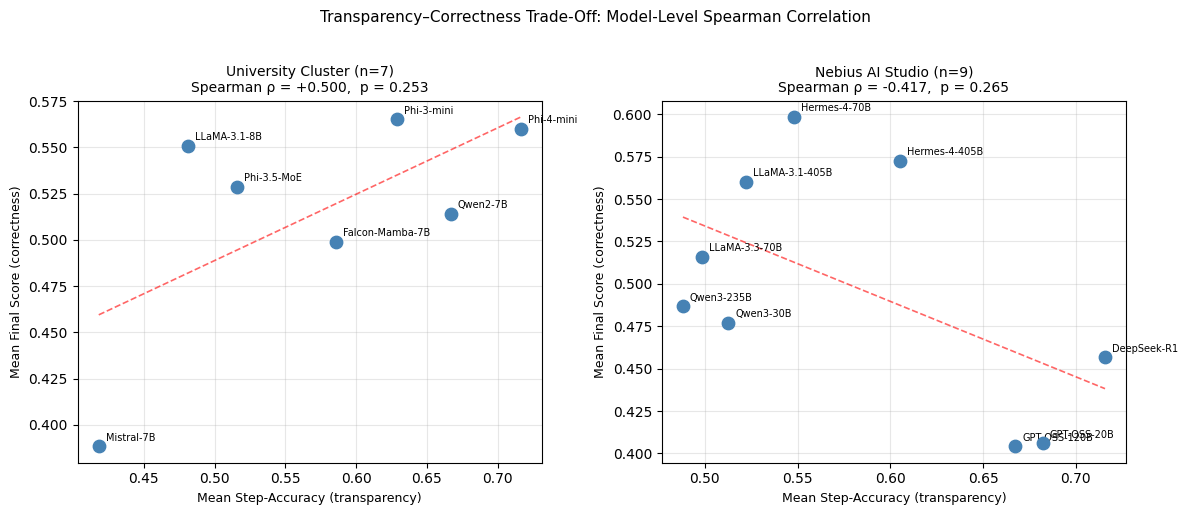

✓ Saved transparency_correctness_scatter.pdf / .png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, tag, models, step_m, final_m, rho, p_val in [
    (axes[0], 'University Cluster (n=7)', m_uc,  s_uc,  f_uc,  rho_uc,  p_uc),
    (axes[1], 'Nebius AI Studio (n=9)',   m_neb, s_neb, f_neb, rho_neb, p_neb),
]:
    ax.scatter(step_m, final_m, s=80, zorder=5, color='steelblue')
    for m, s, f in zip(models, step_m, final_m):
        ax.annotate(m, (s, f), textcoords='offset points',
                    xytext=(5, 4), fontsize=7)
    # Trend line
    z = np.polyfit(step_m, final_m, 1)
    xs = np.linspace(min(step_m), max(step_m), 100)
    ax.plot(xs, np.poly1d(z)(xs), 'r--', alpha=0.6, linewidth=1.2)
    p_str = f'p = {p_val:.3f}' if p_val >= 0.001 else 'p < 0.001'
    ax.set_title(f'{tag}\nSpearman ρ = {rho:+.3f},  {p_str}', fontsize=10)
    ax.set_xlabel('Mean Step-Accuracy (transparency)', fontsize=9)
    ax.set_ylabel('Mean Final Score (correctness)', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Transparency–Correctness Trade-Off: Model-Level Spearman Correlation',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('transparency_correctness_scatter.pdf', bbox_inches='tight', dpi=150)
plt.savefig('transparency_correctness_scatter.png', bbox_inches='tight', dpi=150)
plt.show()
print('✓ Saved transparency_correctness_scatter.pdf / .png')

---
## 6. Summary for Reviewer Response

In [ ]:
print('=' * 70)
print('📋 SUMMARY FOR REVIEWER RESPONSE')
print('=' * 70)
print(f"""
Transparency–Correctness Trade-Off: Spearman Correlation Analysis

Model-level (aggregate means):
  University Cluster (n=7):  ρ = {rho_uc:+.4f},  p = {p_uc:.4f}
  Nebius AI Studio  (n=9):   ρ = {rho_neb:+.4f},  p = {p_neb:.4f}

Interpretation:
  • Nebius shows a negative correlation in the expected direction
    (higher transparency → lower final score), consistent with the
    trade-off claim. The UC shows a positive correlation, driven by
    Mistral-7B (low on both metrics) inflating the relationship.
  • Neither reaches significance at α = 0.05, which is expected
    given the very small number of model-level observations (n ≤ 9).
    With n=9, Spearman requires |ρ| ≥ 0.683 for p < 0.05 (two-tailed).
  • Problem-level within-model correlations (n=57–79) provide higher
    power; see Section 4 above for per-model results.
  • The trade-off is thus best characterised as a descriptive pattern
    across architecturally distinct model families (DeepSeek-R1 vs.
    Qwen3/Hermes) rather than a statistically universal relationship.
""")
print('=' * 70)

📋 SUMMARY FOR REVIEWER RESPONSE

Transparency–Correctness Trade-Off: Spearman Correlation Analysis

Model-level (aggregate means):
  University Cluster (n=7):  ρ = +0.5000,  p = 0.2532
  Nebius AI Studio  (n=9):   ρ = -0.4167,  p = 0.2646

Interpretation:
  • Nebius shows a negative correlation in the expected direction
    (higher transparency → lower final score), consistent with the
    trade-off claim. The UC shows a positive correlation, driven by
    Mistral-7B (low on both metrics) inflating the relationship.
  • Neither reaches significance at α = 0.05, which is expected
    given the very small number of model-level observations (n ≤ 9).
    With n=9, Spearman requires |ρ| ≥ 0.683 for p < 0.05 (two-tailed).
  • Problem-level within-model correlations (n=57–79) provide higher
    power; see Section 4 above for per-model results.
  • The trade-off is thus best characterised as a descriptive pattern
    across architecturally distinct model families (DeepSeek-R1 vs.
    Qwen3/Her

---
## 7. Download Results

In [ ]:
output = {
    'model_level': {
        'university_cluster': {
            'n': len(m_uc), 'spearman_rho': float(rho_uc), 'p_value': float(p_uc),
            'models': [{'model': m, 'step': float(s), 'final': float(f)}
                       for m, s, f in zip(m_uc, s_uc, f_uc)]
        },
        'nebius_ai_studio': {
            'n': len(m_neb), 'spearman_rho': float(rho_neb), 'p_value': float(p_neb),
            'models': [{'model': m, 'step': float(s), 'final': float(f)}
                       for m, s, f in zip(m_neb, s_neb, f_neb)]
        }
    },
    'problem_level': {
        'university_cluster': res_uc,
        'nebius_ai_studio'  : res_neb
    }
}

import json
with open('transparency_correctness_results.json', 'w') as f:
    json.dump(output, f, indent=2)
print('✓ Saved transparency_correctness_results.json')

from google.colab import files as colab_files
for fname in [
    'transparency_correctness_results.json',
    'transparency_correctness_scatter.pdf',
    'transparency_correctness_scatter.png',
]:
    if os.path.exists(fname):
        colab_files.download(fname)
print('✓ Downloads triggered')

✓ Saved transparency_correctness_results.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Downloads triggered
